# URBAN FLOOD STRESS | Census

Notebook reproducible para construir contexto demográfico, social y económico a nivel de tracto para NYC.

Flujo:
- descargar ACS 5-year desde la API del Census Bureau,
- bajar TIGER/Line tracts,
- unir atributos ACS + geometría,
- recortar/etiquetar con boroughs de NYC,
- guardar salidas en `data/spatial/vector/census/`.

El diseño sigue la lógica del repo base `ml4c-pro`:
- ACS 5-year 2024,
- TIGER/Line tracts,
- GEOID como llave de unión,
- variables derivadas de pobreza, renta, vehículos y educación.

1. Economía y Pobreza (Capacidad de Recuperación)TemaClave de TablaDescripción / UsoPobreza GeneralS1701Porcentaje de individuos y familias bajo el umbral de pobreza.Pobreza DetalladaB17001Pobreza desglosada por edad y sexo (crítico para niños/ancianos).Mediana de IngresosB19013Ingreso familiar medio (capacidad de ahorro/seguros).Perfil EconómicoDP03Resumen de empleo, ocupación y tipos de ingresos.Ingresos EspecíficosB19057 / B22001Ingresos por Asistencia Pública, Seguridad Social o SNAP.2. Educación y Factores Sociales (Navegación Institucional)TemaClave de TablaDescripción / UsoNivel EducativoS1501Máximo grado alcanzado (indicador de acceso a trámites).MatriculaciónB15001Nivel educativo desglosado por edad y sexo.Idioma (LEP)C16002Hogares con dominio limitado del inglés (barrera de comunicación).Estado Civil/VeteranosDP02Perfil social; incluye veteranía y estructura del hogar.Migración/OrigenB05002Lugar de nacimiento (ayuda a identificar poblaciones migrantes).3. Vivienda y Vehículos (Vulnerabilidad Física y Evacuación)TemaClave de TablaDescripción / UsoDisponibilidad VehicularB25044Número de autos (0, 1, 2+). Clave para planes de evacuación.Perfil de ViviendaDP04Datos generales: calefacción, plomería y costos de servicios.Tenencia (Renters)B25003Inquilinos vs. Dueños (los inquilinos tienen menos control sobre reparaciones).HacinamientoB25014Más de 1.5 personas/habitación (indicador de sótanos en NYC).Unidades en EdificioB25024Tamaño del edificio (casas unifamiliares vs. complejos grandes).Antigüedad EdificioB25034Año de construcción (indica estándares de drenaje pre-FEMA).4. Conectividad y Salud (Respuesta de Emergencia)TemaClave de TablaDescripción / UsoInternet / DigitalB28002Acceso a banda ancha (vital para alertas y solicitudes de ayuda).DiscapacidadS1810Tipos de discapacidad (movilidad, visión, audición).Mayores SolosB11007Población de 65+ que vive sola (alta prioridad en rescate).

In [1]:
from __future__ import annotations

import os
import sys
import zipfile
from pathlib import Path
from typing import Iterable

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

MPLCONFIGDIR = Path('/tmp/matplotlib')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook fallback
    display = print

plt.style.use('seaborn-v0_8-whitegrid')

def find_project_root(start: Path | None = None) -> Path:
    """Return the repository root."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('No se encontro la raiz del proyecto.')


ROOT = find_project_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from project_name.utils import ensure_directory

CENSUS_YEAR = 2024
ACS_SURVEY = 'acs/acs5'
ACS_BASE_URL = 'https://api.census.gov/data'
NY_STATE_FIPS = '36'
NYC_COUNTIES = {
    'Bronx': '005',
    'Brooklyn': '047',
    'Manhattan': '061',
    'Queens': '081',
    'Staten Island': '085',
}
ACS_VARIABLES = {
    'B19013_001E': 'median_household_income',
    'B17001_002E': 'people_below_poverty',
    'B17001_001E': 'population_for_poverty',
    'B25003_003E': 'renter_occupied_units',
    'B25003_001E': 'occupied_units',
    'B02001_002E': 'white_alone',
    'B02001_003E': 'black_alone',
    'B03003_003E': 'hispanic_or_latino',
    'B03003_001E': 'population_ethnicity',
    'B15003_001E': 'education_population',
    'B15003_022E': 'bachelors',
    'B15003_023E': 'masters',
    'B15003_024E': 'professional_school',
    'B15003_025E': 'doctorate',
    'B08201_002E': 'households_no_vehicle',
    'B08201_001E': 'households_total',
}

BOUNDARY_PATH = ROOT / 'data/spatial/vector/nyc_borough_boundary/nybb.geojson'
RAW_DIR = ensure_directory(ROOT / 'data/spatial/vector/census/raw')
PROCESSED_DIR = ensure_directory(ROOT / 'data/spatial/vector/census')
RAW_ACS_CSV = RAW_DIR / f'acs_{CENSUS_YEAR}_nyc_tracts_raw.csv'
TIGER_ZIP = RAW_DIR / f'tl_{CENSUS_YEAR}_{NY_STATE_FIPS}_tract.zip'
TRACTS_GPKG = PROCESSED_DIR / f'acs_{CENSUS_YEAR}_nyc_tracts.gpkg'
TRACTS_CSV = PROCESSED_DIR / f'acs_{CENSUS_YEAR}_nyc_tracts.csv'
TRACTS_GEOJSON = PROCESSED_DIR / f'acs_{CENSUS_YEAR}_nyc_tracts.geojson'
BOROUGH_SUMMARY_CSV = PROCESSED_DIR / f'acs_{CENSUS_YEAR}_borough_summary.csv'

CENSUS_API_KEY = os.getenv('CENSUS_API_KEY')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

print(ROOT)
print(PROCESSED_DIR)
print(RAW_DIR)


/home/map10194/Documents/urban-flood-stress
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/census
/home/map10194/Documents/urban-flood-stress/data/spatial/vector/census/raw


In [2]:
def first_existing_column(columns: Iterable[str], *candidates: str) -> str | None:
    """Return the first column that exists from a candidate list."""
    column_set = {str(col) for col in columns}
    for candidate in candidates:
        if candidate in column_set:
            return candidate
    return None


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Return a safe ratio with zero denominators mapped to NaN."""
    denominator = pd.to_numeric(denominator, errors='coerce').replace(0, np.nan)
    numerator = pd.to_numeric(numerator, errors='coerce')
    return numerator / denominator


def fetch_acs(
    year: int,
    survey: str,
    variable_map: dict[str, str],
    counties: dict[str, str],
    *,
    api_key: str | None = None,
) -> pd.DataFrame:
    """Download ACS tract estimates for NYC counties."""
    url = f'{ACS_BASE_URL}/{year}/{survey}'
    variables = ','.join(variable_map.keys())
    session = requests.Session()
    frames = []

    for county_name, county_fips in counties.items():
        params = {
            'get': f'NAME,{variables}',
            'for': 'tract:*',
            'in': f'state:{NY_STATE_FIPS} county:{county_fips}',
        }
        if api_key:
            params['key'] = api_key
        response = session.get(url, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()
        header, rows = payload[0], payload[1:]
        county_frame = pd.DataFrame(rows, columns=header)
        county_frame['county_name'] = county_name
        frames.append(county_frame)

    return pd.concat(frames, ignore_index=True)


def download_tiger_tracts(year: int, raw_dir: Path) -> Path:
    """Download the TIGER/Line tract archive for New York State."""
    raw_dir.mkdir(parents=True, exist_ok=True)
    zip_path = raw_dir / f'tl_{year}_{NY_STATE_FIPS}_tract.zip'
    if zip_path.exists():
        return zip_path

    url = (
        f'https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/'
        f'tl_{year}_{NY_STATE_FIPS}_tract.zip'
    )
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    zip_path.write_bytes(response.content)
    return zip_path


def read_tiger_zip(zip_path: Path) -> gpd.GeoDataFrame:
    """Read a TIGER tract zip as a GeoDataFrame in EPSG:2263."""
    with zipfile.ZipFile(zip_path) as zf:
        shp_name = next(name for name in zf.namelist() if name.endswith('.shp'))
    virtual_path = f'zip://{zip_path}!{shp_name}'
    return gpd.read_file(virtual_path).to_crs(epsg=2263)


def normalize_acs_frame(frame: pd.DataFrame, variable_map: dict[str, str]) -> pd.DataFrame:
    """Rename ACS fields and create tract-level socioeconomic ratios."""
    renamed = frame.rename(columns=variable_map).copy()

    for column in renamed.columns:
        if column not in {'state', 'county', 'tract', 'GEOID', 'county_name'}:
            renamed[column] = pd.to_numeric(renamed[column], errors='coerce')

    renamed['GEOID'] = (
        renamed['state'].astype(str)
        + renamed['county'].astype(str)
        + renamed['tract'].astype(str)
    )

    renamed['poverty_rate'] = safe_ratio(
        renamed['people_below_poverty'],
        renamed['population_for_poverty'],
    )
    renamed['renter_share'] = safe_ratio(
        renamed['renter_occupied_units'],
        renamed['occupied_units'],
    )
    renamed['households_no_vehicle_share'] = safe_ratio(
        renamed['households_no_vehicle'],
        renamed['households_total'],
    )
    renamed['hispanic_share'] = safe_ratio(
        renamed['hispanic_or_latino'],
        renamed['population_ethnicity'],
    )
    renamed['bachelors_plus_share'] = safe_ratio(
        renamed[['bachelors', 'masters', 'professional_school', 'doctorate']].sum(axis=1),
        renamed['education_population'],
    )
    renamed['white_share'] = safe_ratio(
        renamed['white_alone'],
        renamed['population_ethnicity'],
    )
    renamed['black_share'] = safe_ratio(
        renamed['black_alone'],
        renamed['population_ethnicity'],
    )
    return renamed


def merge_acs_with_tracts(acs: pd.DataFrame, tracts: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Join ACS attributes to tract geometries by GEOID."""
    tract_geoid_col = 'GEOID' if 'GEOID' in tracts.columns else 'GEOIDFQ'
    merged = tracts.merge(
        acs,
        left_on=tract_geoid_col,
        right_on='GEOID',
        how='inner',
    )
    return gpd.GeoDataFrame(merged, geometry='geometry', crs=tracts.crs)


def add_borough_context(tracts: gpd.GeoDataFrame, boundary_path: Path) -> gpd.GeoDataFrame:
    """Attach a borough label using NYC borough boundaries."""
    boundary = gpd.read_file(boundary_path)
    boundary = boundary.to_crs(tracts.crs)
    borough_col = first_existing_column(boundary.columns, 'BoroName', 'borough', 'boro_name', 'borough_name')
    if borough_col is None:
        raise KeyError('No borough name column found in nybb.geojson')
    boroughs = boundary[[borough_col, 'geometry']].rename(columns={borough_col: 'borough'})

    joined = gpd.sjoin(tracts, boroughs, how='left', predicate='intersects')
    if 'index_right' in joined.columns:
        joined = joined.drop(columns=['index_right'])

    joined = joined.drop_duplicates(subset=['GEOID']).copy()
    return joined


def summarize_boroughs(frame: gpd.GeoDataFrame) -> pd.DataFrame:
    """Build a small borough-level summary from tract estimates."""
    summary = (
        frame.groupby('borough', as_index=False)
        .agg(
            tract_count=('GEOID', 'nunique'),
            median_income_mean=('median_household_income', 'mean'),
            median_income_median=('median_household_income', 'median'),
            poverty_rate_mean=('poverty_rate', 'mean'),
            poverty_rate_median=('poverty_rate', 'median'),
            renter_share_mean=('renter_share', 'mean'),
            no_vehicle_share_mean=('households_no_vehicle_share', 'mean'),
            bachelors_plus_share_mean=('bachelors_plus_share', 'mean'),
        )
        .sort_values('tract_count', ascending=False)
    )
    return summary


In [3]:
def build_or_load_census_layer() -> tuple[gpd.GeoDataFrame, pd.DataFrame, str]:
    """Create the processed census tract layer or load it from cache."""
    if TRACTS_GPKG.exists() and TRACTS_CSV.exists() and RAW_ACS_CSV.exists():
        tracts = gpd.read_file(TRACTS_GPKG)
        raw_acs = pd.read_csv(RAW_ACS_CSV, low_memory=False)
        return tracts, raw_acs, 'cached'

    raw_acs = fetch_acs(
        CENSUS_YEAR,
        ACS_SURVEY,
        ACS_VARIABLES,
        NYC_COUNTIES,
        api_key=CENSUS_API_KEY,
    )
    raw_acs.to_csv(RAW_ACS_CSV, index=False)

    tiger_zip = download_tiger_tracts(CENSUS_YEAR, RAW_DIR)
    tracts = read_tiger_zip(tiger_zip)
    acs = normalize_acs_frame(raw_acs, ACS_VARIABLES)
    merged = merge_acs_with_tracts(acs, tracts)
    merged = add_borough_context(merged, BOUNDARY_PATH)
    merged['census_processed'] = True
    merged['census_year'] = CENSUS_YEAR

    merged.to_file(TRACTS_GPKG, driver='GPKG')
    merged.drop(columns='geometry').to_csv(TRACTS_CSV, index=False)
    merged.to_file(TRACTS_GEOJSON, driver='GeoJSON')

    borough_summary = summarize_boroughs(merged)
    borough_summary.to_csv(BOROUGH_SUMMARY_CSV, index=False)
    return merged, raw_acs, 'downloaded'


In [4]:
census_tracts, raw_acs, source_status = build_or_load_census_layer()
borough_summary = summarize_boroughs(census_tracts)

print('source_status:', source_status)
print('tracts:', len(census_tracts))
print('raw ACS rows:', len(raw_acs))
print('processed layer:', TRACTS_GPKG)
print('processed csv:', TRACTS_CSV)
print('processed geojson:', TRACTS_GEOJSON)
print('borough summary:', BOROUGH_SUMMARY_CSV)

display(
    census_tracts[
        [
            'GEOID', 'borough', 'median_household_income', 'poverty_rate',
            'renter_share', 'households_no_vehicle_share', 'bachelors_plus_share',
            'geometry',
        ]
    ].head()
)
display(borough_summary)

validation = pd.DataFrame(
    {
        'metric': [
            'tracts_total',
            'boroughs_total',
            'raw_acs_rows',
            'missing_income_rows_pct',
            'missing_poverty_rows_pct',
            'missing_borough_rows_pct',
        ],
        'value': [
            len(census_tracts),
            census_tracts['borough'].nunique(dropna=True),
            len(raw_acs),
            round(census_tracts['median_household_income'].isna().mean() * 100, 2),
            round(census_tracts['poverty_rate'].isna().mean() * 100, 2),
            round(census_tracts['borough'].isna().mean() * 100, 2),
        ],
    }
)
display(validation)


source_status: downloaded
tracts: 2327
raw ACS rows: 2327
processed layer: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/census/acs_2024_nyc_tracts.gpkg
processed csv: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/census/acs_2024_nyc_tracts.csv
processed geojson: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/census/acs_2024_nyc_tracts.geojson
borough summary: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/census/acs_2024_borough_summary.csv


,GEOID,borough,median_household_income,poverty_rate,renter_share,households_no_vehicle_share,bachelors_plus_share,geometry
0,36081003400,NaN,74922,0.197764,0.530220,0.417582,0.201555,"POLYGON ((1021333.167 188208.899, 1021555.475 ..."
1,36081003900,NaN,59988,0.197297,0.901734,0.327553,0.352720,"POLYGON ((999956.409 216410.025, 1000186.577 2..."
2,36081003600,NaN,64459,0.135053,0.558879,0.344860,0.219366,"POLYGON ((1021942.135 187912.544, 1022052.181 ..."
3,36081003700,NaN,-666666666,NaN,NaN,NaN,NaN,"POLYGON ((997890.317 214461.418, 997898.898 21..."
4,36081003800,NaN,86146,0.116758,0.552707,0.350427,0.287326,"POLYGON ((1025075.082 188602.546, 1025309.57 1..."


,borough,tract_count,median_income_mean,median_income_median,poverty_rate_mean,poverty_rate_median,renter_share_mean,no_vehicle_share_mean,bachelors_plus_share_mean
0,Bronx,4,-666666666.0,-666666666.0,0.333333,0.333333,NaN,NaN,0.011509
2,Manhattan,2,-333260357.5,-333260357.5,0.054971,0.054971,0.141640,0.204473,0.337061
3,Queens,2,-333295350.0,-333295350.0,0.212747,0.212747,0.665422,0.280060,0.476171
1,Brooklyn,1,-666666666.0,-666666666.0,NaN,NaN,NaN,NaN,NaN
4,Staten Island,1,-666666666.0,-666666666.0,NaN,NaN,NaN,NaN,NaN


,metric,value
0,tracts_total,2327.00
1,boroughs_total,5.00
2,raw_acs_rows,2327.00
3,missing_income_rows_pct,0.00
4,missing_poverty_rows_pct,3.78
5,missing_borough_rows_pct,99.57


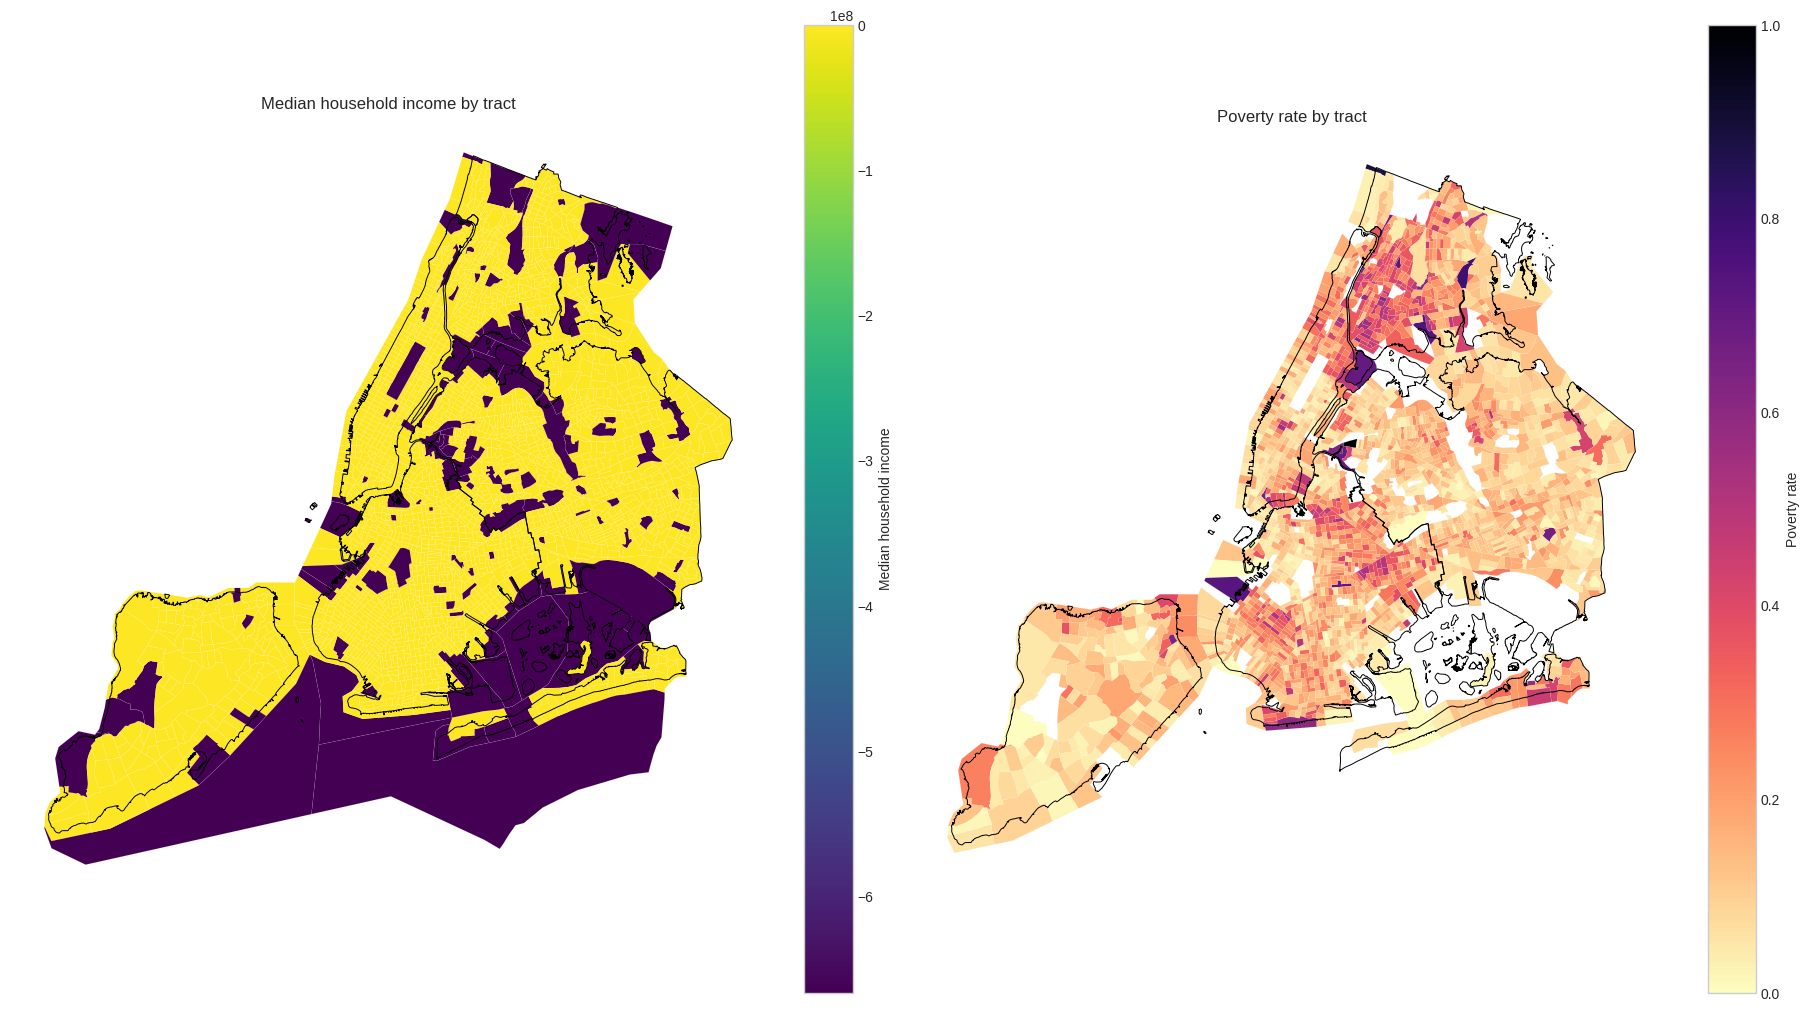

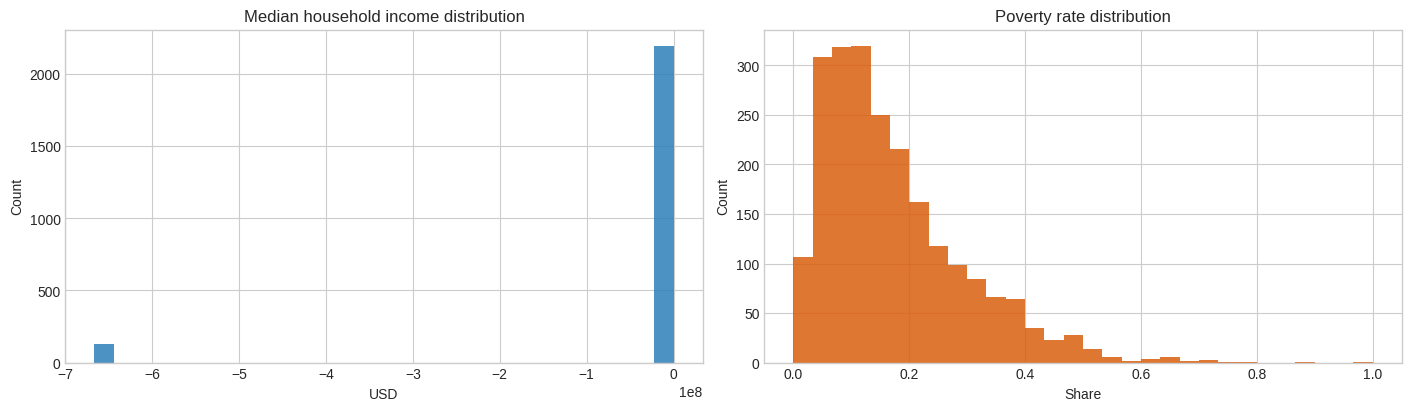

In [5]:
if TRACTS_GPKG.exists():
    boundary = gpd.read_file(BOUNDARY_PATH).to_crs(census_tracts.crs)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10), constrained_layout=True)

    census_tracts.plot(
        ax=axes[0],
        column='median_household_income',
        cmap='viridis',
        linewidth=0.05,
        edgecolor='white',
        legend=True,
        legend_kwds={'label': 'Median household income'},
    )
    boundary.boundary.plot(ax=axes[0], color='black', linewidth=0.7)
    axes[0].set_title('Median household income by tract')
    axes[0].set_axis_off()

    census_tracts.plot(
        ax=axes[1],
        column='poverty_rate',
        cmap='magma_r',
        linewidth=0.05,
        edgecolor='white',
        legend=True,
        legend_kwds={'label': 'Poverty rate'},
    )
    boundary.boundary.plot(ax=axes[1], color='black', linewidth=0.7)
    axes[1].set_title('Poverty rate by tract')
    axes[1].set_axis_off()

    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    census_tracts['median_household_income'].dropna().plot.hist(ax=axes[0], bins=30, color='#2c7fb8', alpha=0.85)
    axes[0].set_title('Median household income distribution')
    axes[0].set_xlabel('USD')
    axes[0].set_ylabel('Count')

    census_tracts['poverty_rate'].dropna().plot.hist(ax=axes[1], bins=30, color='#d95f0e', alpha=0.85)
    axes[1].set_title('Poverty rate distribution')
    axes[1].set_xlabel('Share')
    axes[1].set_ylabel('Count')

    plt.show()
